# Facial Expression Classification with CNN

## Goal

The goal of this project is to build and evaluate convolutional neural network models that can classify facial expressions from grayscale facial images.

The dataset used for this is FER-2013, which contains 48x48 pixel grayscale images divided into emotion classes.

1. Understand the dataset
2. Prepare image data
3. Build first CNN model
4. Train and evaluate the model
5. Improve the model through experimentation
6. Make predictions on unseen images
7. Analyze the results and limitations

In [43]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tensorflow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 1. Understanding the data

Before building a model, I first have to inspect how the dataset is structured. Since the images are stored in folders by class, the folder names represent the emotion labels.

The dataset is already split into training and test folders, which makes it suitable for supervised image classification.

In [2]:
from pathlib import Path

data_dir = Path("data")
train_dir = data_dir / "train"
test_dir = data_dir / "test"

print("Training directory exists:", train_dir.exists())
print("Testing directory exists:", test_dir.exists())

Training directory exists: True
Testing directory exists: True


In [3]:
class_names = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])

print("Classes:")
print(class_names)
print("Number of classes:", len(class_names))

Classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of classes: 7


The dataset contains seven emotion classes: angry, disgust, fear, happy, neutral, sad and surprise. Since each class is stored in its own folder, the folder structure can be used directly when loading the images into Tensorflow.

In [4]:
def count_images_in_directory(directory):
    counts = {}
    for class_name in class_names:
        class_path = directory / class_name
        counts[class_name] = len(list(class_path.glob("*.jpg")))
    return counts

train_counts = count_images_in_directory(train_dir)
test_counts = count_images_in_directory(test_dir)

counts_df = pd.DataFrame({
    "Class": class_names,
    "Train Count": [train_counts[class_name] for class_name in class_names],
    "Test Count": [test_counts[class_name] for class_name in class_names]
})

counts_df["Total"] = counts_df["Train Count"] + counts_df["Test Count"]

counts_df

,Class,Train Count,Test Count,Total
0,angry,3995,958,4953
1,disgust,436,111,547
2,fear,4097,1024,5121
3,happy,7215,1774,8989
4,neutral,4965,1233,6198
5,sad,4830,1247,6077
6,surprise,3171,831,4002


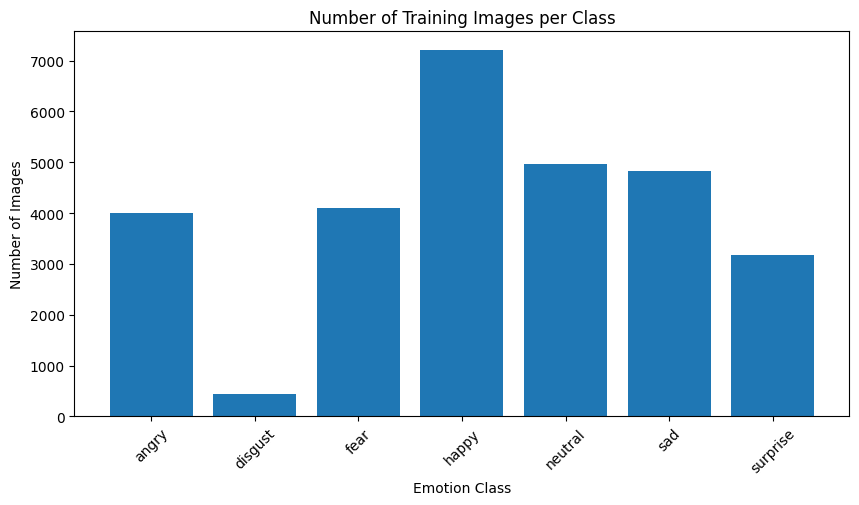

In [5]:
plt.figure(figsize=(10, 5))
plt.bar(counts_df["Class"], counts_df["Train Count"])
plt.title("Number of Training Images per Class")
plt.xlabel("Emotion Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

The class distribution shows that the dataset is imbalanced. Some classes have more training images compared to others.

This may affect the model, because it can become better at predicting common classes and worse at predicting classes with fewer examples.

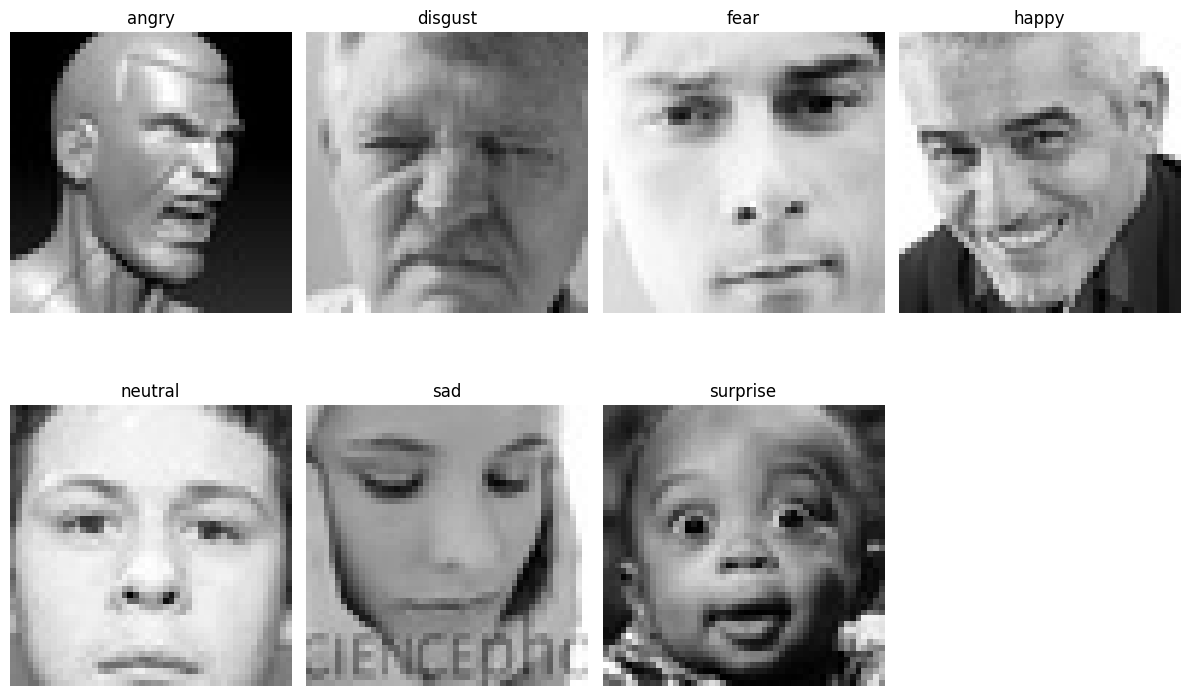

In [6]:
plt.figure(figsize=(12, 8))

for i, class_name in enumerate(class_names):
    class_folder = train_dir / class_name
    image_path = random.choice(list(class_folder.glob("*.jpg")))

    img = tf.keras.utils.load_img(image_path, target_size=(48, 48), color_mode="grayscale")
    img_array = tf.keras.utils.img_to_array(img)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img_array.squeeze(), cmap="gray")
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

The images are grayscale and only 48x48 pixels. This makes the classification task challenging. 

Some emotion classes also look visually similar, for example fear and surprise or sad and neutral may look visually similar.

## 2. Preparing the Data

The images need to be loaded into TensorFlow datasets before training. Since the dataset is relatively large, I will first work with a smaller subset to test that the model and training pipeline work correctly.

The images are resized to 48x48 pixels and loaded as grayscale images. Pixel values will be normalized later from a range of 0-255 to 0-1.

In [7]:
IMG_SIZE = (48, 48)
BATCH_SIZE = 64
COLOR_MODE = "grayscale"
NUM_CLASSES = len(class_names)

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of classes:", NUM_CLASSES)

Image size: (48, 48)
Batch size: 64
Number of classes: 7


In [8]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    color_mode=COLOR_MODE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    color_mode=COLOR_MODE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    color_mode=COLOR_MODE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names
print("Class names:", class_names)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.
Found 7178 files belonging to 7 classes.
Class names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [9]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Pixel value range:", images.numpy().min(), "to", images.numpy().max())

Image batch shape: (64, 48, 48, 1)
Label batch shape: (64, 7)
Pixel value range: 0.0 to 255.0


The image batches have the shape: (64, 48, 48, 1).

64 images will be processed at the same time in one batch.
48x48 image size.
1 means the image is grayscaled.

The labels are one-hot encoded, meaning that each label is represented as a vector with seven possible values, one for each emotion class.

The pixel values are currently between 0 and 255, so they need to be normalized before being used by the network.

In [10]:
# Smaller datasets for faster experimentation
# This makes it easier to test that the model and training loop work without waiting for a long time.

train_small = train_ds.take(100)  # 100 batches (6400 images)
val_small = val_ds.take(25)       # 25 batches (1600 images)

print("Small training dataset batches:", len(list(train_small)))
print("Small validation dataset batches:", len(list(val_small)))

Small training dataset batches: 100
Small validation dataset batches: 25


In [11]:
AUTOTUNE = tf.data.AUTOTUNE

train_small = train_small.prefetch(buffer_size=AUTOTUNE)
val_small = val_small.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

I first use a smaller subset of the training data to test the model quickly. This is useful because larger experiments can take time and it is better to confirm that the model works before scaling up.

The test dataset is kept separate and will only be used for final evaluation.

## 3. Model 1: Baseline CNN

The first model is a simple convolutional neural network. The goal is not to create the best model immediately, but to build a working baseline that can learn from image data.

In [12]:
model_1 = keras.Sequential([
    layers.Input(shape=(48, 48, 1)),

    # Normalize pixel values from 0-255 to 0-1
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       409,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 428,935 (1.64 MB)

 Trainable params: 428,935 (1.64 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model_1.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [14]:
EPOCHS_MODEL_1 = 5

history_1 = model_1.fit(
    train_small,
    validation_data=val_small,
    epochs=EPOCHS_MODEL_1
)

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.2592 - loss: 1.8120 - val_accuracy: 0.2656 - val_loss: 1.7654
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3184 - loss: 1.7049 - val_accuracy: 0.3413 - val_loss: 1.6579
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3750 - loss: 1.6124 - val_accuracy: 0.3688 - val_loss: 1.6288
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3981 - loss: 1.5585 - val_accuracy: 0.3613 - val_loss: 1.6133
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4338 - loss: 1.5008 - val_accuracy: 0.3925 - val_loss: 1.5473


In [15]:
# Plot function for training history
def plot_training_history(history, title):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Training Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.legend(loc="lower right")
    plt.title(f"{title} - Accuracy")

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Training Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.legend(loc="upper right")
    plt.title(f"{title} - Loss")

    plt.tight_layout()
    plt.show()

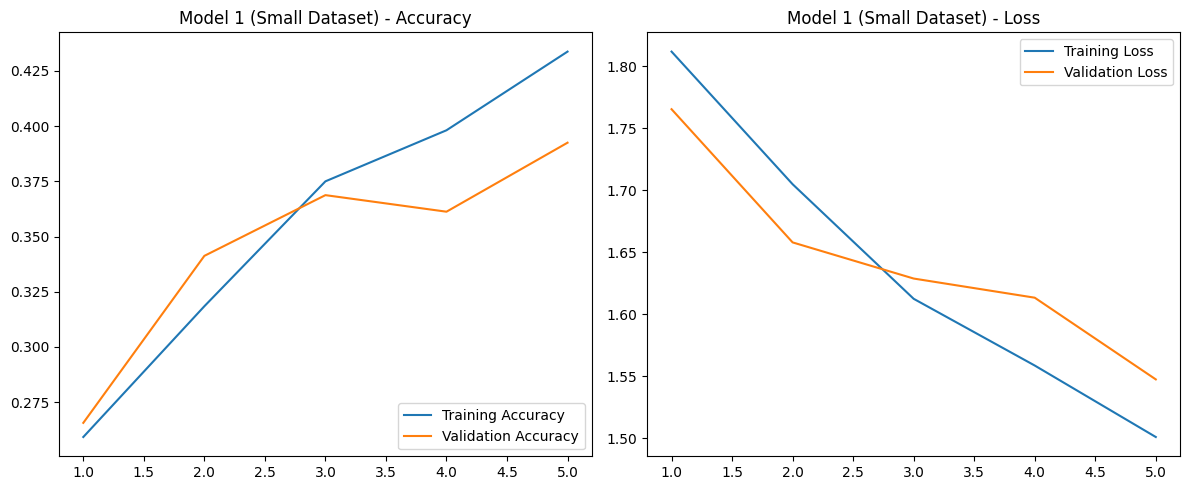

In [16]:
plot_training_history(history_1, "Model 1 (Small Dataset)")

### Model 1 Evaluation

After training the baseline model, I evaluate it on the separate test dataset. The test dataset has not been used during training, so it gives a better estimate of how the model performs on unseen images.

In [17]:
model_1_test_loss, model_1_test_acc = model_1.evaluate(test_ds)

print("Model 1 Test Loss:", model_1_test_loss)
print("Model 1 Test Accuracy:", model_1_test_acc)

113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.4106 - loss: 1.5299
Model 1 Test Loss: 1.5298858880996704
Model 1 Test Accuracy: 0.4105600416660309


### Model 1 Results

The baseline CNN reached a test accuracy of about 41%. This is clearly better than random guessing across seven classes, which would be around 14%.

The training curves show that both training and validation accuracy improve over the five epochs, while both losses decrease. This indicates that the model is learning useful patterns from the image data in a reasonable way.

There is no strong sign of severe overfitting at this stage, since validation performance also improves. However, the overall accuracy is still limited which suggests that the model is very simple and may not have enough capacity to fully capture the differences between all the different facial expressions.

This gives a reasonable baseline for comparison with a more improved CNN model.

## 4. Training and improving the model: Model 2

The baseline model learned useful patterns but had limited accuracy. In this second experiment, I improve the CNN by using a deeper architecture and adding techniques that can help generalization.

The changes in Model 2 are:

- More convolutional layers
- Batch normalization
- Dropout
- Data augmentation
- More training epochs
- Early stopping

The purpose is to test whether these changes improve performance on validation and test data

In [18]:
# Data augmentation and early stopping for improved performance
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08)
])

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [20]:
model_2 = keras.Sequential([
    layers.Input(shape=(48, 48, 1)),

    # Data augmentation layer, only active during training
    data_augmentation,

    # Normalize pixel values
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model_2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 685,703 (2.62 MB)

 Trainable params: 684,743 (2.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [22]:
model_2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [23]:
EPOCHS_MODEL_2 = 15

history_2 = model_2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_MODEL_2,
    callbacks=[early_stopping]
)

Epoch 1/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.2505 - loss: 1.9133 - val_accuracy: 0.2336 - val_loss: 2.0220
Epoch 2/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.3122 - loss: 1.7192 - val_accuracy: 0.3656 - val_loss: 1.6110
Epoch 3/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.3453 - loss: 1.6566 - val_accuracy: 0.3984 - val_loss: 1.5398
Epoch 4/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.3809 - loss: 1.5917 - val_accuracy: 0.4071 - val_loss: 1.4994
Epoch 5/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.3938 - loss: 1.5497 - val_accuracy: 0.4332 - val_loss: 1.4640
Epoch 6/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.4163 - loss: 1.5114 - val_accuracy: 0.4510 - val_loss: 1.4290
Epoch 7/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.4230 - loss: 1.4847 - val_accuracy: 0.4632 - val_loss: 1.4034
Epoch 8/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.4414 - loss: 1.4571 - 

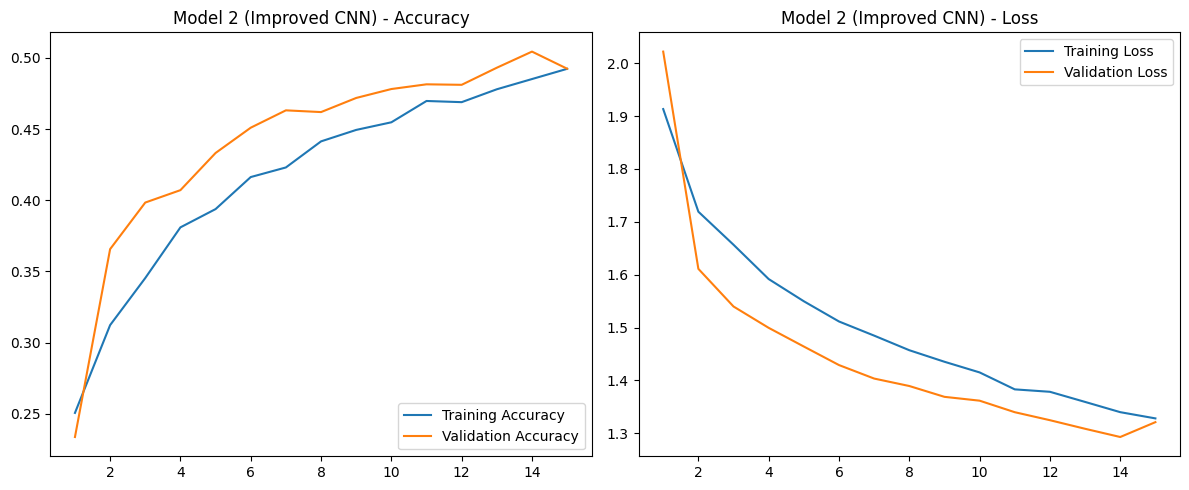

In [25]:
plot_training_history(history_2, "Model 2 (Improved CNN)")

### Model 2 Training Interpretation

Model 2 shows a clear improvement compared to the baseline model. The validation accuracy reaches around 50%, while the validation loss decreases during training.

There still is no strong sign of overfitting, because training and validation performance stay relatively close. In some epochs, validation accuracy is even higher than training accuracy. This could happen because data augmentation and even dropout make the overall training process harder for the model, while validation is evaluated on unmodified images.

However, the accuracy is still not very high. This shows that facial expression classification is not an easy task to do. Some emotions can look similar and the images are small grayscale images with very limited detail.

### Model 2 Test Evaluation

After training Model 2, I evaluate it on the seperate test dataset. This will show how well the improved model performs on some unseen images.

In [26]:
model_2_test_loss, model_2_test_acc = model_2.evaluate(test_ds)

print("Model 2 Test Loss:", model_2_test_loss)
print("Model 2 Test Accuracy:", model_2_test_acc)

113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5024 - loss: 1.2945
Model 2 Test Loss: 1.2944682836532593
Model 2 Test Accuracy: 0.5023683309555054


### Model 2 Test Results

Model 2 achieved a test accuracy of about 50.2%. This is higher than Model 1, which only reached about 41.1%.

The test accuracy is also close to the validation accuracy during training. This is a positive sign because it suggests the model generalizes well to unseen data and is not only memorizing the training images.

### 4.1 Model 3: Optimized CNN

Model 2 improved the baseline result, but the accuracy was still limited. Because of this I will test a third model to see if a more stable CNN architecture can improve the result further.

Model 3 keeps some ideas from Model 2 but changes how they are used.

The main changes are:

- A deeper convolutional structure with repeated Conv2D layers in each block
- More careful data augmentation with smaller transformations
- Dropout after several convolutional blocks, not only near the final dense layer
- GlobalAveragePooling2D instead of flatten to reduce the number of parameters
- ReduceLROnPlateau to lower the learning rate when validation loss stops improving

The overall goal is to improve generalization and test whether a more stable architecture gives better performance than the previous model.

In [ ]:
# Data augmentation with smaller transformations to improve generalization
data_augmentation_3 = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.05),
    layers.RandomTranslation(0.05, 0.05)
])
# Early stopping with more patience to allow for longer training
early_stopping_3 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)
# Learning rate scheduler to reduce learning rate if validation loss plateaus
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [44]:
model_3 = keras.Sequential([
    layers.Input(shape=(48, 48, 1)),

    # More careful data augmentation
    data_augmentation_3,
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.15),

    # Block 2
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.20),

    # Block 3
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 4
    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    # Classification head
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.45),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model_3.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 6, 6, 256)      │         1,02

 Total params: 653,031 (2.49 MB)

 Trainable params: 651,111 (2.48 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [30]:
model_3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [31]:
EPOCHS_MODEL_3 = 30

history_3 = model_3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_MODEL_3,
    callbacks=[early_stopping_3, reduce_lr]
)

Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - accuracy: 0.2102 - loss: 2.2554 - val_accuracy: 0.2440 - val_loss: 2.3761 - learning_rate: 5.0000e-04
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - accuracy: 0.2997 - loss: 1.8758 - val_accuracy: 0.3611 - val_loss: 1.6496 - learning_rate: 5.0000e-04
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.3746 - loss: 1.6492 - val_accuracy: 0.4391 - val_loss: 1.4427 - learning_rate: 5.0000e-04
Epoch 4/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.4242 - loss: 1.4962 - val_accuracy: 0.4391 - val_loss: 1.4163 - learning_rate: 5.0000e-04
Epoch 5/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - accuracy: 0.4684 - loss: 1.3904 - val_accuracy: 0.4844 - val_loss: 1.3896 - learning_rate: 5.0000e-04
Epoch 6/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.4923 - loss: 1.3303 - val_accuracy: 0.4630 - val_loss: 1.3762 - learning_rate: 5.0000e-04
Epoch 7/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/ste

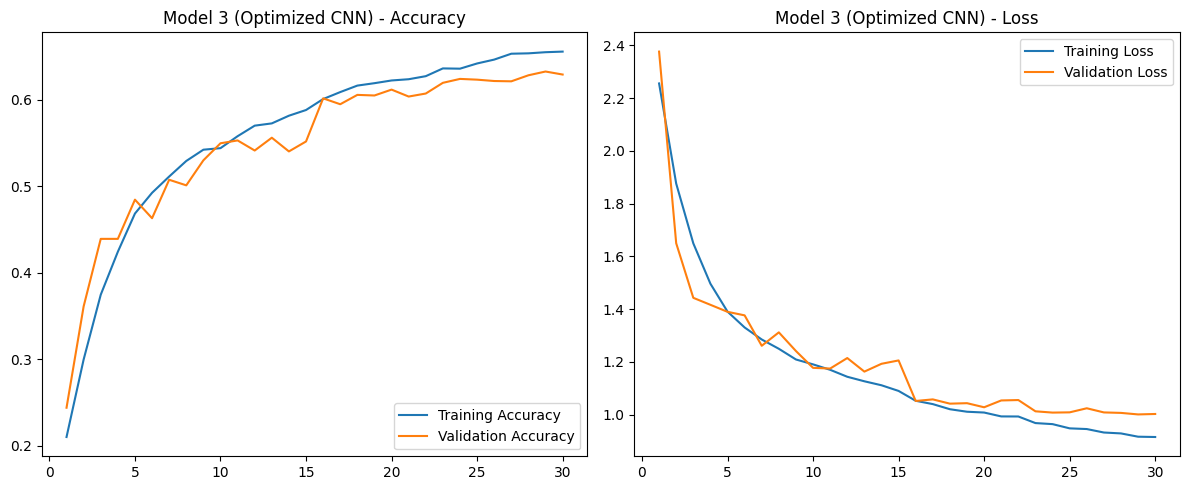

In [32]:
plot_training_history(history_3, "Model 3 (Optimized CNN)")


### Model 3 Training Interpretation

Model 3 shows a clear improvement compared to the previous models. The training accuracy increases steadily and the validation accuracy reaches around 63%, which is much higher than both Model 1 & 2.

The loss curves also improve during training. Both training and validation loss decrease.

There is a small gap between training and validation performance near the end, which may indicate some mild overfitting. The gap however is not extreme and the validation accuracy remains close to the test accuracy. This seems to suggest that Model 3 generalizes reasonably well.

The improvements likely come from the deeper convolutional structure, more careful data augmentation, dropout in several parts of the model, GlobalAveragePooling2D and learning rate reduction during the overall training.

In [33]:
model_3_test_loss, model_3_test_acc = model_3.evaluate(test_ds)

print("Model 3 Test Loss:", model_3_test_loss)
print("Model 3 Test Accuracy:", model_3_test_acc)

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6287 - loss: 0.9974
Model 3 Test Loss: 0.9974018931388855
Model 3 Test Accuracy: 0.6287266612052917


### Model 3 Test Results

Model 3 achieved a test accuracy of about 62.9% which is the best result so far. This is a strong improvement over both Model 1 & 2.

The test accuracy is very close to the validation accuracy that was achieved during training, which indicates that the model generalizes well to unseen data. This is important because the goal is not only to perform well on training data, but also to classify new facial images correctly.

In [34]:
model_results = pd.DataFrame({
    "Model": ["Model 1 (Small Dataset)", "Model 2 (Improved CNN)", "Model 3 (Optimized CNN)"],
    "Test Loss": [model_1_test_loss, model_2_test_loss, model_3_test_loss],
    "Test Accuracy": [model_1_test_acc, model_2_test_acc, model_3_test_acc]
})
model_results

,Model,Test Loss,Test Accuracy
0,Model 1 (Small Dataset),1.529886,0.410560
1,Model 2 (Improved CNN),1.294468,0.502368
2,Model 3 (Optimized CNN),0.997402,0.628727


### Model Comparison

The three models show a clear iterative improvement process.

Model 1 was a simple baseline CNN trained on a smaller subset of the data. It reached about 41% test accuracy which showed that the model was learning, but the overall architecture was still very limited.

Model 2 used a deeper CNN, full training data, batch normalization, dropout, data augmentation and more epochs. This improved the test accuracy to about 50%.

Model 3 performed best, reaching about 63% test accuracy. This implies that more stable architecture, repeated convolutional blocks, GlobalAveragePooling2D, learning rate scheduling and structured dropout helped make the model better and to generalize better.

This comparison shows that model performance depends not only on using more layers, but also on how the model is structured, regularized and trained.

## 5. Evaluation on Test Data

Model 3 had the best test accuracy, so I use it as the final model for deeper evaluation

Accuracy gives a useful overall score, but it does not show which emotion classes are easier or harder for the model. To understand this better, I will use a confusion matrix and a classification report.

In [35]:
final_model = model_3

In [36]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = final_model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Number of test images:", len(y_true))

Number of test images: 7178


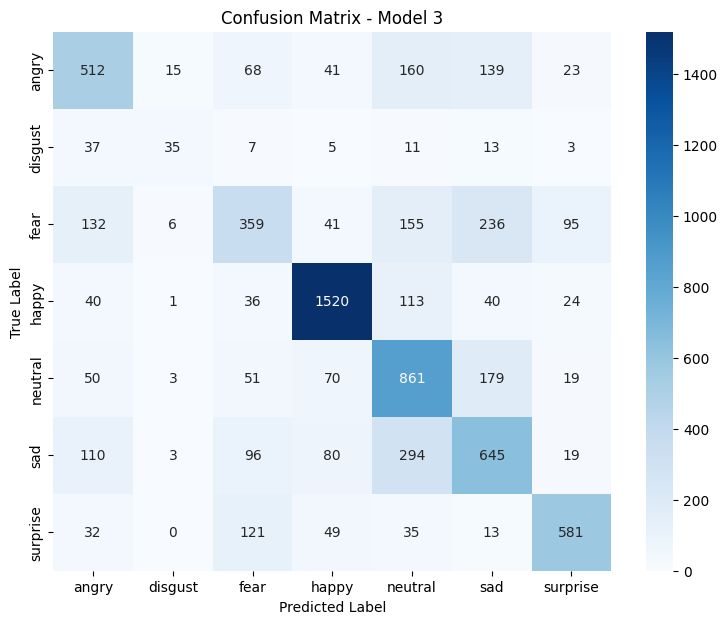

In [37]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)

plt.title("Confusion Matrix - Model 3")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [38]:
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

report_df = pd.DataFrame(report).transpose()
report_df

,precision,recall,f1-score,support
angry,0.560789,0.534447,0.547301,958.000000
disgust,0.555556,0.315315,0.402299,111.000000
fear,0.486450,0.350586,0.407491,1024.000000
happy,0.841639,0.856821,0.849162,1774.000000
neutral,0.528545,0.698297,0.601677,1233.000000
sad,0.509881,0.517241,0.513535,1247.000000
surprise,0.760471,0.699158,0.728527,831.000000
accuracy,0.628727,0.628727,0.628727,0.628727
macro avg,0.606190,0.567409,0.578570,7178.000000
weighted avg,0.628248,0.628727,0.624172,7178.000000


### Evaluation Interpretation

Model 3 achieved an overall test accuracy of about 62.9% which was without a doubt the best result of the three models. The weighted average F1-score is also around 0.62 which shows that the model performs reasonably well overall.

The confusion matrix and classification report show that the model performs better on some emotion classes than others. The model is strongest on "happy", where it has both high precision and high recall. It also performs reasonably well on "surprise".

The most difficult classes are "fear" and "disgust". The "disgust" class has very few test images compared to other classes, which likely makes it harder for the model to learn this emotion properly. The "fear" class is also often confused with other emotions like "sad", "surprise" and "neutral".

There is also some confusion between "sad" and "neutral" which is understandable because those expressions can look very similar in small 48x48 grayscale images. Overall the results are good for this project. The model has learned useful patterns, but the performance differs clearly between the classes.

## 6. Prediction on a New Image

In this step, I use the trained model as a program to predict the emotion class of a single image.

The image is loaded, resized to 48x48 pixels, converted to grayscale and passed into the model using the same preprocessing format as the training data.

I will first test the prediction code on an image from the test folder. This image was not used during training.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


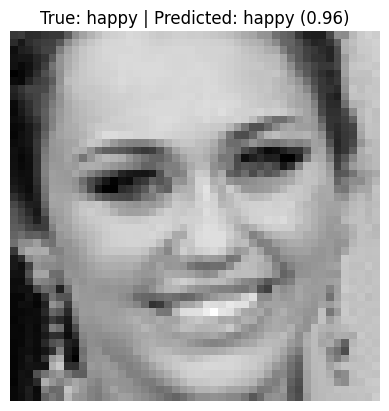

True class: happy
Predicted class: happy
Confidence: 0.9608761


In [39]:
true_class = "happy"
image_path = random.choice(list((test_dir / true_class).glob("*.jpg")))

img = tf.keras.utils.load_img(image_path, color_mode="grayscale", target_size=IMG_SIZE)

img_array = tf.keras.utils.img_to_array(img)
img_batch = np.expand_dims(img_array, axis=0)

prediction = final_model.predict(img_batch)
predicted_index = np.argmax(prediction)
predicted_class = class_names[predicted_index]
confidence = np.max(prediction)

plt.imshow(img_array.squeeze(), cmap="gray")
plt.title(f"True: {true_class} | Predicted: {predicted_class} ({confidence:.2f})")
plt.axis("off")
plt.show()

print("True class:", true_class)
print("Predicted class:", predicted_class)
print("Confidence:", confidence)

### Prediction on Test Image

The model correctly predicted the selected test image as "happy" with high confidence. This makes sense because "happy" was one of the strongest classes in the classification report, with high precision and recall

This shows that the trained CNN can be used to make predictions on unseen images, but this image still comes from the FER-2013 test set, so it has the same style and format as the training data. To test the model further, I will also try images that are outside the original dataset.

### Prediction on Own Images

To test the model on more realistic new data, I'll use two of my own images, one happy expression and one neutral expression. This should challenge the model more due to different lighting, framing, background and image quality.

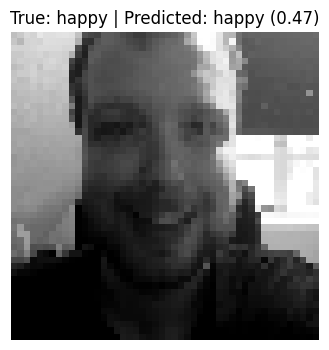

Image: data\new_images\my_happy.jpg
Expected emotion: happy
Predicted emotion: happy
Confidence: 0.4705
----------------------------------------


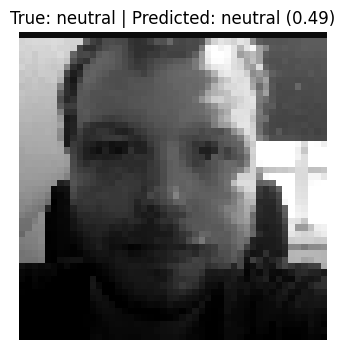

Image: data\new_images\my_neutral.jpg
Expected emotion: neutral
Predicted emotion: neutral
Confidence: 0.486
----------------------------------------


In [41]:
custom_images = {
    "happy": Path("data/new_images/my_happy.jpg"),
    "neutral": Path("data/new_images/my_neutral.jpg")
}

for true_label, image_path in custom_images.items():
    img = tf.keras.utils.load_img(image_path, color_mode="grayscale", target_size=IMG_SIZE)

    img_array = tf.keras.utils.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)

    prediction = final_model.predict(img_batch, verbose=0)
    predicted_index = np.argmax(prediction)
    predicted_class = class_names[predicted_index]
    confidence = np.max(prediction)

    plt.figure(figsize=(4, 4))
    plt.imshow(img_array.squeeze(), cmap="gray")
    plt.title(f"True: {true_label} | Predicted: {predicted_class} ({confidence:.2f})")
    plt.axis("off")
    plt.show()

    print("Image:", image_path)
    print("Expected emotion:", true_label)
    print("Predicted emotion:", predicted_class)
    print("Confidence:", round(float(confidence), 4))
    print("-" * 40)

### Own Images Prediction Interpretation

The model correctly predicted both my own images. The happy images was predicted as "happy" and the neutral image was predicted as "neutral".

However the confidence scores were only around 0.47-0.49 which is lower than the confidence when using images from the dataset. This makes sense because my own images differ very much from the training data in terms of lighting, how the image is framed, background details, the angle of the face and overall image quality.

This confirms that the model can generalize to images outside the original dataset to some extent, but it is less certain when the images are not in the same format as the given dataset. This is an important limitation when thinking about using the model in any real application

## 7. Result Analysis

### How well does the model work?

The final model (Model 3) achieved about 62.9% in test accuracy. This is clearly better than random guessing across seven classes. It is also better than the earlier models where Model 1 only reached 41% and Model 2 50%.

This demonstrates that the model learned image patterns in a positive way and that the improvements made when making Model 3 had a positive effect on the overall result.

### Signs of overfitting or underfitting

Model 3 does not show strong signs of severe overfitting. The training accuracy and validation accuracy are relatively close and the test accuracy is also close to the validation accuracy.

There may be some mild overfitting near the end because training accuracy is slightly higher than validation accuracy, but the gap is not very large.

The model also does not seem to be underfitting because both training and validation performance improved clearly during training.

### Difference between training and test performance

The training result was a little higher than the test results, which is normal since the model has learned directly from the training images. What matters more is that the validation and test accuracy ended up very close to each other. To me, this suggests that the model is not memorizing the training data, but can also handle similar unseen images from the FER-2013 dataset reasonably well.

When I tried two of my own images, the model predicted both of them correctly. But the confidence was lower compared to the test image from the dataset. This makes sense because my own photos are not exactly the same as in the dataset when it comes to lighting, stuff in the background, where my face is positioned and the image quality is different, so the model is less certain.

### What affected the result the most?

The biggest improvement came from changing the model architecture and training setup. Model 3 used repeated convolutional blocks, batch normalization, dropout, GlobalAveragePooling2D, more careful data augmentation and learning rate reduction.

The dataset itself also affected the result. Some classes had fewer images compared to others. Also some emotions are very similar visually, which makes it harder to predict.

### Limitations

The model is limited by the small image size, the grayscale format, class imbalance and similarity between facial expressions. It is also only trained on the FER-2013 dataset, so performance may be weaker on real-world images (like my own images).

The model should therefore be seen as a learning project and basic prototype, not as a production-ready system for predicting emotions.

Deep learning is a good choice for this project because the input data consists of images, where spatial patterns such as eyes, mouth shape and facial structure matter. At the same time, it requires enough representative data to generalize well.

## Saving the Final Model

Since Model 3 is the best model I have, I save it as the final trained model.

In [42]:
# Save the final model
final_model.save("fer2013_model_3_optimized.keras")
print("Model saved as fer2013_model_3_optimized.keras")

Model saved as fer2013_model_3_optimized.keras


## 8. Reflection

The hardest part of this assignment was not only building a working CNN model, but understanding why the results changed between the different model versions. At first, the baseline worked but the accuracy was limited. I then had to experiment with deeper models, dropout, data augmentation and learning rate scheduling to improve the result to a result I was happy with.

I learned that deep learning is very iterative. A more complex model does not automatically mean a better model. In this case, the third model performed best because it had better structure and trained in a more stable manner. I also learned that it is important to look at more than just accuracy.
Also the confusion matrix and the classification report showed that some emotions were much harder to classify than others.

If I started over, I would probably spend more time on class imbalance and image preprocessing earlier in the process. For example, I could test class weights, stronger face cropping or more carefully selected data augmentation. I would also test more models, but in a more structured way so that each experiment changes only one or two things at a time, but this takes a lot of training time.

I think this submission corresponds to a VG level. I built and evaluated a working CNN model, compared several different model variants, improved the model through each experimentation, analyzed training curves, used a confusion matrix and a classification report, tested the model on new images and discussed limitations such as overfitting,. class imbalance, generalization and differences between dataset images and real-world images.